In [1]:
%matplotlib inline
import numpy as np
import cv2
import matplotlib.pyplot as plt

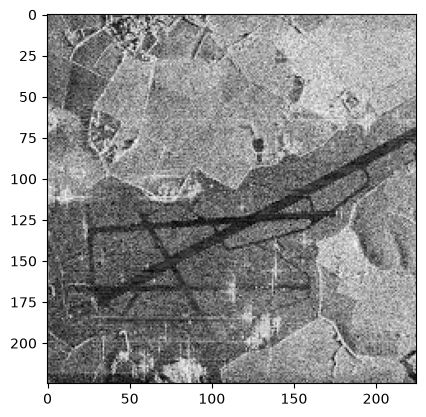

In [2]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

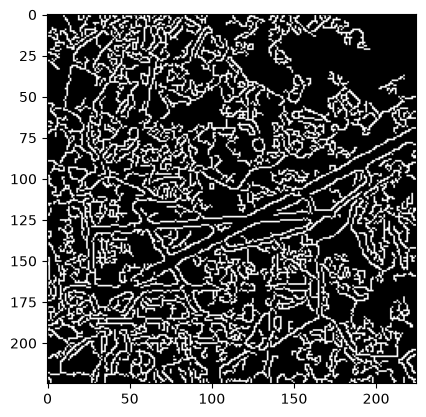

In [27]:
#Canny
blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)
edges = cv2.Canny(blurred, 40, 120, apertureSize=3)
plt.imshow(edges, cmap="gray")

Наиболее протяжённый участок длиной 116.30 пикселей
Координаты: (121, 123) -> (224, 69)


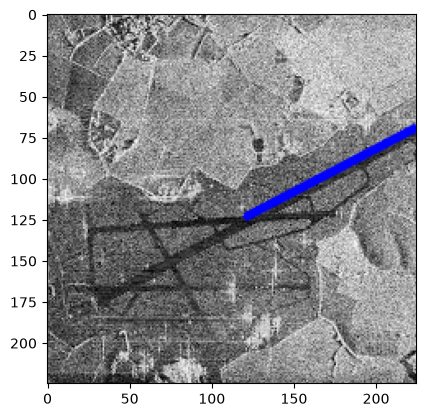

In [28]:
# Преобразование Хафа
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=60,
                        minLineLength=40, maxLineGap=5)

# Поиск самого длинного отрезка
longest_line = None
max_length = 0

import math 

if lines is not None:
    for i in range(0, len(lines)):
        x1, y1, x2, y2 = lines[i][0]
        length = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if length > max_length:
            max_length = length
            longest_line = lines[i][0]

# Отрисовка самого протяжённого участка
result_image = image.copy()
if longest_line is not None:
    x1, y1, x2, y2 = longest_line
    cv2.line(result_image, (x1, y1), (x2, y2), (0, 0, 255), 3, cv2.LINE_AA)
    print(f"Наиболее протяжённый участок длиной {max_length:.2f} пикселей")
    print(f"Координаты: ({x1}, {y1}) -> ({x2}, {y2})")
plt.imshow(result_image)

In [5]:
# 1. Точечная бинаризация
import copy

bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

In [6]:
# 2. Бинаризация Отсу
_, th2 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [7]:
# 3. Адаптивная бинаризация
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 71, 21)

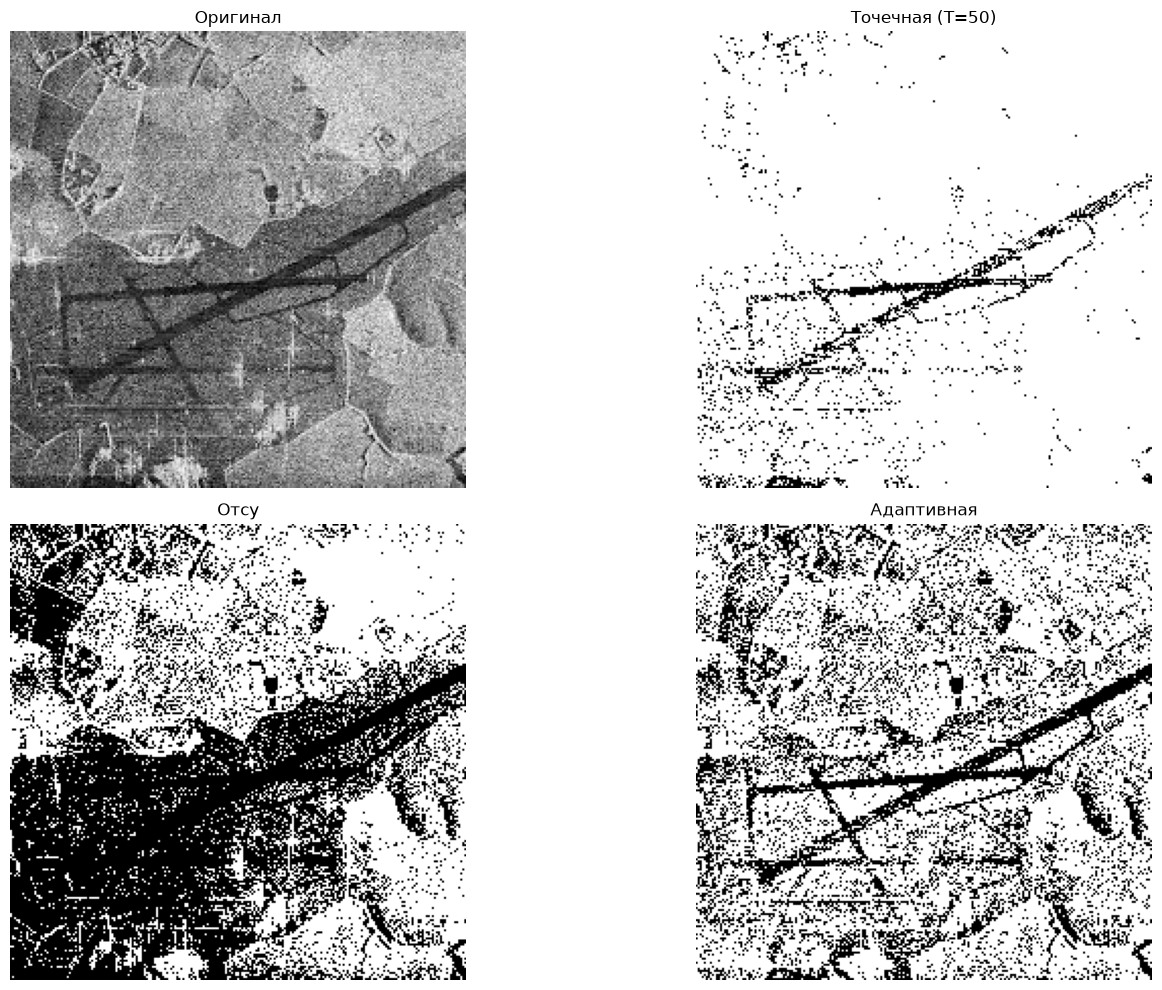

In [8]:
# Сравнение всех методов
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_gray, cmap="gray")
plt.title('Оригинал')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(bin_img, cmap="gray")
plt.title(f'Точечная (T={T})')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(th2, cmap="gray")
plt.title('Отсу')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(th3, cmap="gray")
plt.title('Адаптивная')
plt.axis('off')

plt.tight_layout()
plt.show()

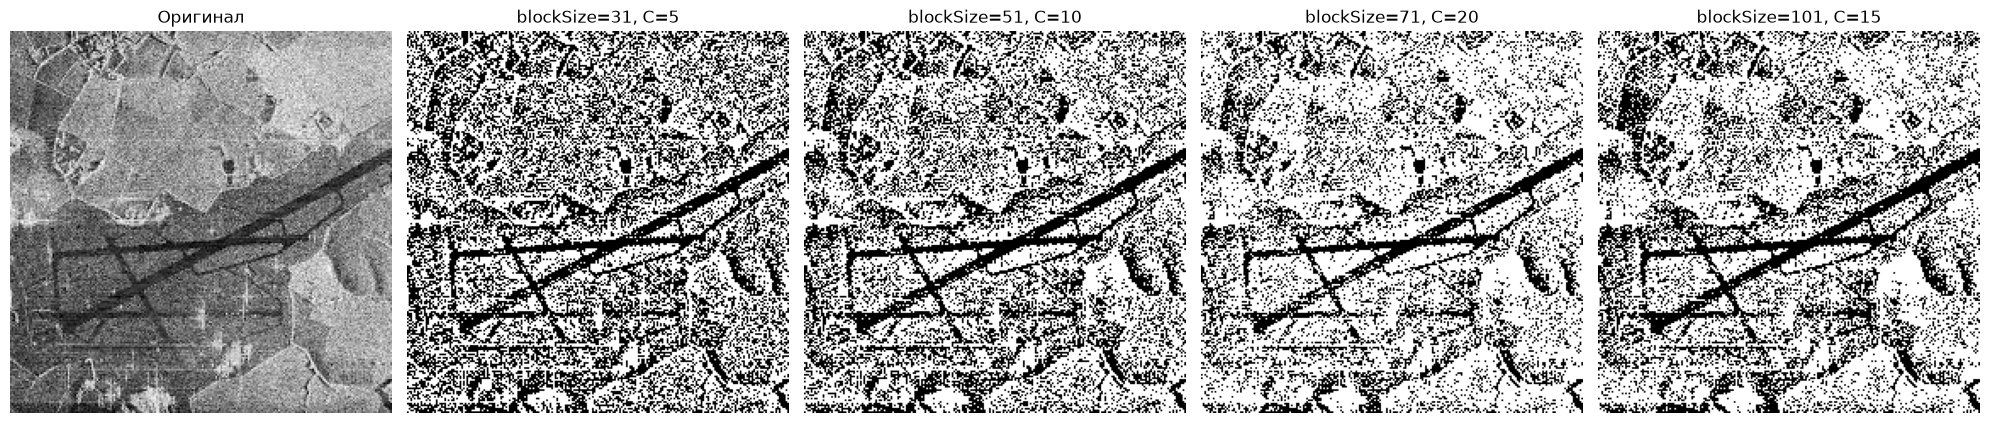

In [9]:
params = [(31, 5), (51, 10), (71, 20), (101, 15)]

plt.figure(figsize=(20, 5))

plt.subplot(1, len(params) + 1, 1)
plt.imshow(image_gray, cmap="gray")
plt.title('Оригинал')
plt.axis('off')

for i, (bs, c) in enumerate(params):
    th = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, bs, c)
    plt.subplot(1, len(params) + 1, i + 2)
    plt.imshow(th, cmap="gray")
    plt.title(f'blockSize={bs}, C={c}')
    plt.axis('off')

plt.tight_layout()
plt.show()

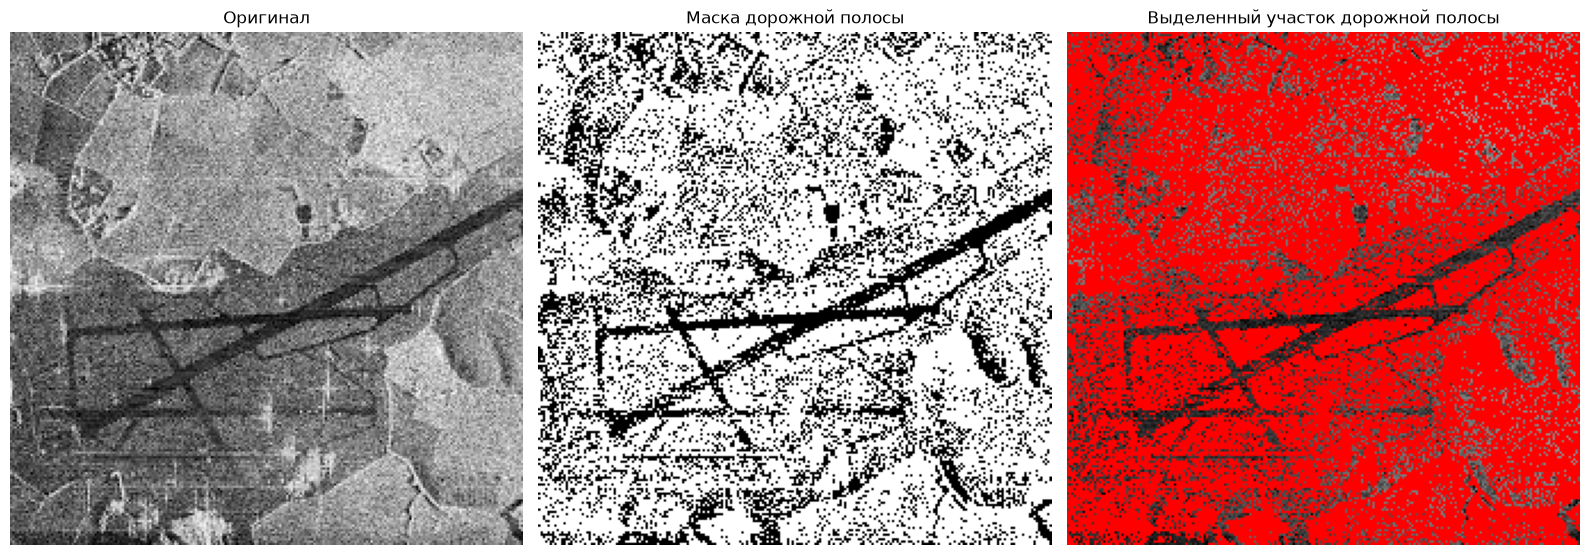

In [10]:
# Выделение дорожной полосы - адаптивная (71, 20)
road_mask = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 71, 21)
road_highlight = image.copy()
road_highlight[road_mask == 255] = (0, 0, 255)

plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(road_mask, cmap="gray")
plt.title('Маска дорожной полосы')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(road_highlight, cv2.COLOR_BGR2RGB))
plt.title('Выделенный участок дорожной полосы')
plt.axis('off')

plt.tight_layout()
plt.show()